# **Aplikacja do rozwiązywania planszy sudoku**


# **Opis importowanej biblioteki**
Aplikacja wykorzystuje następujące biblioteki:
* **numpy** – do operacji na macierzach i tablicach.
* **matplotlib.pyplot** i **ListedColormap** – do wizualizacji planszy Sudoku.
* **random** – do losowania wartości.
* **time** – do pomiaru czasu wykonania fukcnji.
* **functools.lru_cache** – do optymalizacji funkcji
* **typing**– do definiowania typów zmiennych w stylu Pythona 3.
* **concurrent.futures** – do równoległego tworzenia populacji (przyspieszenie działania).

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import time
from functools import lru_cache
from typing import List, Tuple, Dict, Set, Optional
import concurrent.futures

# **Wizualizacja planszy Sudoku**
Funkcja **display_sudoku()**:
* Tworzy siatkę 9x9 i koloruje pola w zależności od tego, czy są częścią wejściowej planszy (initial) czy rozwiązania (solved).
* Rysuje grube linie co 3 pola, oddzielając bloki 3x3.
* Wypełnia wartości - **czarne pogrubione** (wartości początkowe (initial)), **niebieskie** (wartości wygenerowane przez algorytm).


In [ ]:
# Wizualizacja

def display_sudoku(initial: List[List[int]], solved=None, title=None):

    # Definicja matplot - tabela 9x9
    fig, ax = plt.subplots(figsize=(9, 9))

    # Czy zagadnienie rozwiązane
    if solved is None:
        solved = initial

    # Tworzenie maski zer - definicja nie zapełnionych pól
    mask = np.zeros((9, 9))
    for i in range(9):
        for j in range(9):
            if initial[i][j] != 0:
                mask[i][j] = 1

    # Definicje wyświetlania tablicy
    # Obraz - maska, lista kolorów, bez interpolacji, z zachowaniem proporcji, określone wymiary
    cmap = ListedColormap(['white', 'lightgray'])         # Lista kolorów
    ax.imshow(mask, cmap=cmap, interpolation='none', aspect='equal', extent=[-0.5, 8.5, 8.5, -0.5])


    # Rysowanie siatki tablicy
    for i in range(10):                                   # Iterowanie 0-9
        lw = 2 if i % 3 == 0 else 0.5                     # Grubsza linia dla pól podzielnych przez 3
        ax.axhline(i-0.5, color='black', linewidth=lw)    # Linia horyzontalna
        ax.axvline(i-0.5, color='black', linewidth=lw)    # Linia wertykalna

    # Uzupełnianie liczbami
    for i in range(9):
        for j in range(9):
            if initial[i][j] != 0:            # Wyświetl liczbę tabeli <initial> jeśli !=0
                ax.text(j, i, str(initial[i][j]), ha='center', va='center',
                       fontsize=14, fontweight='bold', color='black')       # Wyświetl liczbę
            elif solved[i][j] != 0:           # Wyświetl liczbę tabeli <solved> jeśli !=0
                ax.text(j, i, str(solved[i][j]), ha='center', va='center',
                       fontsize=12, color='blue')                           # Wyświetl liczbę

    # Parametry wykresu
    ax.set_title(title, fontsize=16, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()



# **Zmiana zagadnienia z ewolucyjnego na genetyczne**
Algorytm ewolucyjny został przekształcony w algorytm genetyczny, który opiera się na typowych mechanizmach:
* Populacja chromosomów,
* Krzyżowanie rodziców,
* Mutacja potomków,
* Selekcja turniejowa,
* Pętla pokoleniowa z możliwością zatrzymania przy stagnacji.

In [ ]:
# Zmiana zagadnienia z ewolucyjnego na genetyczne

def make_gene(initial: List[int] = None) -> List[int]:

    if initial is None:             # Przekazanie (wczytanie) listy lub
        initial = [0] * 9           # .. inicjacja nowej - pustej (zera)

    # Identyfikacja pól stałych (zapełnionych) oraz dostępnych, tzn. nie wykorzystanych liczb
    fixed_positions = {i: val for i, val in enumerate(initial) if val != 0}
    available_nums = set(range(1, 10)) - set(fixed_positions.values())

    # Inicjacja genu zerami
    gene = [0] * 9

    # Najpierw wpisujemy pola stałe na odpowiednią pozycję w zawartości genu
    for pos, val in fixed_positions.items():
        gene[pos] = val

    # Reszta pól zapełniana jest losowo dostępnymi liczbami - dodatkowo randomizowanymi
    available_nums = list(available_nums)
    random.shuffle(available_nums)


    # Zapełnienie genu wartościami stałymi lub losowymi odpowiadającymi konkretnej pozycji genu
    current_idx = 0
    for i in range(9):
        if i not in fixed_positions:
            gene[i] = available_nums[current_idx]
            current_idx += 1

    return gene         # Zwrócenie kompletnego genu (9 pól)

# **Tworzenie chromosomu i populacji**
* Chromosom – reprezentowany jako lista 9 wierszy (każdy to lista 9 liczb).
* Funkcja **make_chromosome()** tworzy chromosom na podstawie wierszy wejściowej planszy, wypełniając je zgodnie z **funkcją make_gene()**.
* Funkcja **make_population()** tworzy wiele takich chromosomów (osobników), korzystając z ThreadPoolExecutor.

In [ ]:
# Tworzenie chromosomu i populacji

def make_chromosome(initial: List[List[int]] = None) -> List[List[int]]:

    if initial is None:                           # Jeśli wczytano pustą listę
        initial = [[0] * 9 for _ in range(9)]     # .. uzupełnij zerami
    return [make_gene(row) for row in initial]    # Zwróć chromosom


# Tworzenie populacji

def make_population(count: int, initial: List[List[int]] = None) -> List[List[List[int]]]:

    if initial is None:                           # Jeśli wczytano pustą listę
        initial = [[0] * 9 for _ in range(9)]     # .. uzupełnij zerami

    # Tworzenie chromosomów w odrębnych wątkach przy użyciu biblioteki <concurrent.futures>
    # Wątków jest tyle ile chromosomów (count); wyniki są zwracane jako lista zbiorcza

    with concurrent.futures.ThreadPoolExecutor() as executor:
        population = list(executor.map(lambda _: make_chromosome(initial), range(count)))

    return population                             # Lista chromosomów - kompletna populacja

# **Zdefiniowanie funkcji celu**
Funkcja **get_fitness()**:
* Zapewnia unikalności wartości w wierszach, kolumnach i blokach 3x3.
* Dopasowanie (fitness = 0) oznacza prawidłową planszę Sudoku.

In [ ]:
# Zdefiniowanie funkcji celu

def calculate_column_fitness(chromosome: List[List[int]]) -> int:

    # Dopasowanie na podstawie warunku kolumn

    fitness = 0
    for i in range(9):
        seen = set()
        duplicates = 0
        for j in range(9):
            num = chromosome[j][i]
            if num in seen:
                duplicates += 1
            seen.add(num)
        fitness -= duplicates
    return fitness

def calculate_block_fitness(chromosome: List[List[int]]) -> int:

    # Dopasowanie na podstawie warunku kwadratów 3x3

    fitness = 0
    for block_row in range(3):
        for block_col in range(3):
            seen = set()
            duplicates = 0
            for i in range(3*block_row, 3*(block_row+1)):
                for j in range(3*block_col, 3*(block_col+1)):
                    num = chromosome[i][j]
                    if num in seen:
                        duplicates += 1
                    seen.add(num)
            fitness -= duplicates
    return fitness

def get_fitness(chromosome: List[List[int]]) -> int:

    # Dopasowanie zbiorcze
    # Prawidłowość dopasowania wierszy jest zapewniona poprzez proces przygotowania genu !

    column_fitness = calculate_column_fitness(chromosome)   # Część warunku kolumn
    block_fitness = calculate_block_fitness(chromosome)     # Część warunku bloków 3x3

    return column_fitness + block_fitness                   # Zbiorcza wartość funkcji celu

# **Krzyżowanie z zachowaniem ustalonych wartości pól**
Funkcja **crossover()**:
* Zapewnia nienaruszalność pól zadanych w initial.
* Dla losowych wierszy (nieustalonych) wykonuje jednopunktowe krzyżowanie (losowy punkt podziału).
* Generuje dwóch potomków (offspring1, offspring2) jako kombinację dwóch rodziców.

In [ ]:
# Krzyżowanie z zachowaniem ustalonych wartości pól

def crossover(parent1: List[List[int]], parent2: List[List[int]], initial: List[List[int]]) -> Tuple[List[List[int]], List[List[int]]]:


    # Definicja dwojga potomków
    offspring1 = []
    offspring2 = []

    for i in range(9):            # Pętla od i do 9

        # Zapewnienie nienaruszalności ustalonych już pól
        if any(initial[i][j] != 0 for j in range(9)):       # Jeśli przynajmniej jedno 'i' ustalone
            if random.random() < 0.5:             # Prawdopodabieństwo krzyżowania 0.5
                offspring1.append(parent1[i])         # Przepisanie tych samych rodziców do kolejnego pokolenia
                offspring2.append(parent2[i])
            else:                                 # Ewentualna zamiana potomków miejscami
                offspring1.append(parent2[i])
                offspring2.append(parent1[i])

        else:  # Dla uzupełnianych losowo wartości krzyżowanie jednopunktowe
            crossover_point = random.randint(1, 7)      # Losowanie punktu przecięcia

            # Przypisanie potomka jako dodawanie fragmentów dwóch chromosomów

            offspring1.append(parent1[i][:crossover_point] + parent2[i][crossover_point:])
            offspring2.append(parent2[i][:crossover_point] + parent1[i][crossover_point:])

    return offspring1, offspring2                 # Zwraca dwóch potomków


# **Optymalizacja mutacji**
Funkcja **mutation()**:

1. Z określonym prawdopodobieństwem pm:
* Duża mutacja – cały wiersz jest generowany na nowo.
*  Mała mutacja – zamieniane są dwie losowe wartości w wierszu (z wyłączeniem ustalonych pozycji).

2. Jeśli brak mutacji, wiersz pozostaje niezmieniony.

In [ ]:
# Zoptymalizowana mutacja

def mutation(population: List[List[int]], pm: float, initial: List[List[int]]) -> List[List[int]]:

    mutated = []        # Definicja listy mutacji

    for i, row in enumerate(population):
        if random.random() < pm:                # Prawdopodobieństwo mutacji 'pm'

            # Mutuj do kompletnie nowego genu
            mutated.append(make_gene(initial[i]))

        elif random.random() < pm * 2:  # Jeśli nie, to wprowadź prawdopodobieństwo mutacji "mniejszej" - (2 * pm)
            new_row = row.copy()        # Robocza kopia wiersza

            # Tworzenie zbioru pól stałych (ustalonych)
            fixed_positions = {x for x, val in enumerate(initial[i]) if val != 0}

            # Tworzenie tablicy pól losowanych
            available_positions = [x for x in range(9) if x not in fixed_positions]

            if len(available_positions) >= 2:     # Jeśli co najmniej 2 dostępne pola ..
                pos1, pos2 = random.sample(available_positions, 2)  # ..losuj dwie pozycje
                new_row[pos1], new_row[pos2] = new_row[pos2], new_row[pos1]  # .. i zamień miejscami (indeksami) kopie robocze wierszy

            mutated.append(new_row)     # Do listy mutacji dodaj kopię roboczą
        else:
            mutated.append(row)         # Jeśli brak mutacji to do listy dodaj wiersz niezmieniony

    return mutated                      # Zwróc wynik mutacji

# **Zastosowana selekcja metodą turniejową**
Funkcja **tournament_selection()**:

* Dla każdego osobnika w nowej populacji losuje **tournament_size** osobników.
* Wybiera najlepszego z nich (o najwyższym fitnessie).
* Tworzy nową populację z najlepszych zawodników każdego turnieju.

In [ ]:
# Selekcja metodą turniejową

def tournament_selection(population: List[List[List[int]]], fitness_values: List[int], tournament_size: int = 5) -> List[List[List[int]]]:

    selected = []                   # Definicja listy wyboru
    pop_size = len(population)      # Liczność populacji

    for _ in range(pop_size):

        # Wybieramy określoną liczbę losowych indeksów z zakresu rozmiaru populacji
        tournament_idxs = random.sample(range(pop_size), tournament_size)

        # Szukanie indeksu zwycięzcy turnieju wg. obliczonej wartości funkcji celu
        best_idx = max(tournament_idxs, key=lambda idx: fitness_values[idx])

        # Dodaj wynik selekcji do listy zwycięzców
        selected.append(population[best_idx])

    return selected     # Zwróć wynik selekcji


# **Pętla głównego algorytmu genetycznego**
Funkcja **genetic_algorithm()**:

Tworzy populację początkową.

W każdej generacji:

* Oblicza funkcję celu dla każdego chromosomu.
* Zapamiętuje najlepszego osobnika (elitarny).
* Wykonuje selekcję turniejową.
* Krzyżuje pary i mutuje potomków.

Zatrzymuje się po osiągnięciu:
* Rozwiązania (fitness = 0),
* Braku poprawy przez 100 generacji (stagnation_counter).

In [ ]:
# Pętla główna algorytmu genetycznego

def genetic_algorithm(initial_board: List[List[int]], pop_size: int = 1000,
                      generations: int = 1000, pm: float = 0.1, pc: float = 0.95,
                      early_stop: bool = True) -> List[List[int]]:

    # Definicje inicjacyjne algorytmu

    population = make_population(pop_size, initial_board)   # Losowanie populcji
    best_fitness_history = []                               # Historia wartości dopasowań
    best_overall_fitness = float('-inf')                    # Najlepsze zupełne dopasowanie
    best_chromosome = None                                  # Najlepszy chromosom
    stagnation_counter = 0                                  # Wskaźnik stagnacji - brak progresu rozwiązania ??
    for gen in range(generations):

        # Obliczenie funkcji celu dla wszystkich chromosomów
        fitness_values = [get_fitness(x) for x in population]

        # Wyszukiwanie najlepiej przystosowanego osobnika
        best_idx = fitness_values.index(max(fitness_values))    # Indeks najlepszego dopasowania
        current_best_fitness = fitness_values[best_idx]         # Obecnie najlepsze dopasowanie
        current_best_chromosome = population[best_idx]          # Obecnie najlepszy chromosom

        # Zaktualizuj rozwiązanie
        if current_best_fitness > best_overall_fitness:         # Jeśli obecne > zupełne
            best_overall_fitness = current_best_fitness         # Zapisz obecne jako zupełne
            best_chromosome = current_best_chromosome           # Przepisz także najlepszy chromosom
            stagnation_counter = 0                              # Nie inkrementuj licznika stagnacji
        else:                                                   # Jeśli obecne <= zupełne
            stagnation_counter += 1                             # .. zwiększ tylko licznik stagnacji

        best_fitness_history.append(best_overall_fitness)       # Zapisz wynik w historii

        # Raportuj co setny wynik oraz wynik ostateczny
        if gen % 100 == 0 or current_best_fitness == 0:
            print(f"Numer pokolenia {gen}: dopasowanie = {current_best_fitness}")

        # Warunek wczesnego zatrzymania
        if current_best_fitness == 0:
            print("Znaleziono rozwiązanie!")
            return current_best_chromosome        # Zwróć wynik

        if early_stop and stagnation_counter >= 100:        # Flaga zatrzymania i konkretny limit wskaźnika stagnacji
            print(f"Przerwano obliczenia po {gen} generacjach ze względu na brak poprawy rozwiązania")
            return best_chromosome                # Zwróć najlepszy znany chromosom

        # Selekcja turniejowa
        selected = tournament_selection(population, fitness_values)

        # Jednostka elitarna
        new_pop = [current_best_chromosome]

        # Krzyżowanie i mutacja w jednej pętli
        for i in range(0, pop_size-1, 2):
            parent1, parent2 = selected[i], selected[(i+1)%pop_size]
            if random.random() < pc:
                parent1, parent2 = crossover(parent1, parent2, initial_board)
            new_pop.extend([mutation(parent1, pm, initial_board), mutation(parent2, pm, initial_board)])

        population = new_pop[:pop_size]   # Zapewnia zachowanie rozmiaru populacji

    return best_chromosome                # Zwraca wynik pracy algorytmu

# **Generowanie planszy Sudoku metodą rekurencyjną**
Funkcje **fillField()** i **fillSudoku()**:

* **fillField()** sprawdza, czy liczba może być wpisana w dane pole (bez powtórzeń w wierszu, kolumnie i bloku 3x3).
* **fillSudoku()** to rekurencyjna funkcja typu backtracking, która wypełnia planszę zgodnie z zasadami Sudoku.
* Użycie **random.shuffle()** zapewnia unikalność każdej wygenerowanej planszy

In [ ]:
# Generowanie planszy SUDOKU metodą rekurencyjną

# Funkcja testu prawidłowości zapełniania tablicy
def fillField(wiersz, kolumna, liczba, SUDOKU):

    # Test unikalności - czy można umieścić 'liczba' w danym 'wiersz' i 'kolumna'
    # Jeśli liczba się powtórzy zwraca False

    if liczba in SUDOKU[wiersz, :]:
        return False
    if liczba in SUDOKU[:, kolumna]:
        return False

    # Sprawdzenie unikalności dla małych kwadratów 3x3
    box_start_wiersz = (wiersz // BOX_SIZE) * BOX_SIZE      # Konwersja indeksu liniowego (początek wiersza boksu)
    box_start_kolumna = (kolumna // BOX_SIZE) * BOX_SIZE    # Konwersja indeksu liniowego (początek kolumny boksu)
    for i in range(box_start_wiersz, box_start_wiersz + BOX_SIZE):        # Wyszukiwanie powtórzeń w wierszu
        for j in range(box_start_kolumna, box_start_kolumna + BOX_SIZE):  # Wyszukiwanie powtórzeń w kolumnie
            if SUDOKU[i, j] == liczba:          # Jeśli znajdzie powtórzenie zwraca False
                return False
    return True                                 # Zwraca True po prawidłowym wykonaniu funkcji


# Funkcja rekurencyjna generowania pełnej planszy SUDOKU
# Każda plansza jest unikalna

def fillSudoku(SUDOKU):

    # Pętla rekurencyjna do wypełniania planszy, iterowana po tablicy SIZE x SIZE
    for i in range(SIZE):
        for j in range(SIZE):
            if SUDOKU[i, j] == 0:                   # Jeśli w polu jest zero ..
                liczby = list(range(1, SIZE + 1))   # .. generuje listę hipotetycznych liczb ..
                random.shuffle(liczby)              # .. i dodatkowo tasuje je - zapewnienie unikalności planszy
                for liczba in liczby:
                    if fillField(i, j, liczba, SUDOKU):   # Test czy pole jest puste funkcją <fillField>
                        SUDOKU[i, j] = liczba             # Jeśli jest puste wpisuje liczbę
                        if fillSudoku(SUDOKU):            # .. i wywołuje samą siebie, aby wypełniać kolejne pola
                            return True                   # Zwraca True jeśli wypełni całą planszę (warunek wyjścia z pętli)
                        SUDOKU[i, j] = 0                  # Jeśli się nie uda przywraca zero na danej pozycji
                return False                              # Zwraca False jeśli żadna liczba nie "pasuje" w danym miejscu - powrót pętle wyżej i ponowna próba
    return True                                           # Zwraca True, gdy plansza gotowa - tzn. funkcja powróci ze wszystkich pętli



# Losowanie planszy o zadanej ilości pól zerowych (pustych)

def losowanie(SUDOKU, ILE_POL):

    # Wypełniamy planszę w sposób spełniający zasady Sudoku
    wypełnione = False              # Dopóki nie wypełniono
    while not wypełnione:
        SUDOKU[:, :] = 0            # Tworzymy pustą planszę - wypełnioną zerami
        if fillSudoku(SUDOKU):      # Zwraca True jeśli <fillSudoku> przygotuje kompletną planszę
            wypełnione = True

    # Losowanie punktów wyzerowanych do utworzenia zagadki

    indexes = np.random.choice(SIZE * SIZE, ILE_POL, replace=False)

    # Konwersja indeksu liniowego na współrzędne dwuwymiarowe

    for i in indexes:
        wiersz = i // SUDOKU.shape[1]       # Wybierz wiersz
        kolumna = i % SUDOKU.shape[1]       # Wybierz kolumnę
        SUDOKU[wiersz, kolumna] = 0         # Wstaw zero

    return SUDOKU                           # Zwraca kompletną zagadkę SUDOKU

# **Działanie fukcji main**
Funkcja main jest główną funkcją programu rozwiązującego zagadkę Sudoku.

1. **Ustawienie parametrów algorytmu**

 POP_SIZE = 1000 - rozmiar populacji (liczba osobników w każdym pokoleniu)

 GENERATIONS = 1000 - maksymalna liczba pokoleń

 PM = 0.1 - prawdopodobieństwo mutacji (10%)

 PC = 0.95 - prawdopodobieństwo krzyżowania (95%)

2. **Parametry Sudoku**

 ILE_POL = 25 - liczba pustych pól (określa trudność)

 SIZE = 9 - standardowy rozmiar planszy Sudoku (9x9)

 BOX_SIZE = 3 - rozmiar podkwadratu (3x3)

 SUDOKU = np.zeros((SIZE, SIZE), dtype=int) - inicjalizacja pustej planszy

3. **Przygotowanie planszy**
  
  (SUDOKU, ILE_POL) - generuje początkową planszę z określoną liczbą pustych pól

 Jeśli wystąpi błąd (initial_board is None), program się zamyka

4. **Wyświetlanie zagadki**

 display_sudoku(initial_board) - pokazuje początkową, nieuzupełnioną planszę

5. **Uruchomienie algorytmu**

 Rozpoczyna pomiar czasu (start_time). Wywołuje główną funkcję algorytmu genetycznego (genetic_algorithm) z podanymi parametrami. Kończy pomiar czasu (end_time)

6. **Wyświetlanie wyników**
  
  Oblicza wartość dopasowania najlepszego rozwiązania (get_fitness(best_solution)). Wyświetla czas wykonania i wartość dopasowania. Pokazuje rozwiązanie (display_sudoku z wypełnionymi polami)

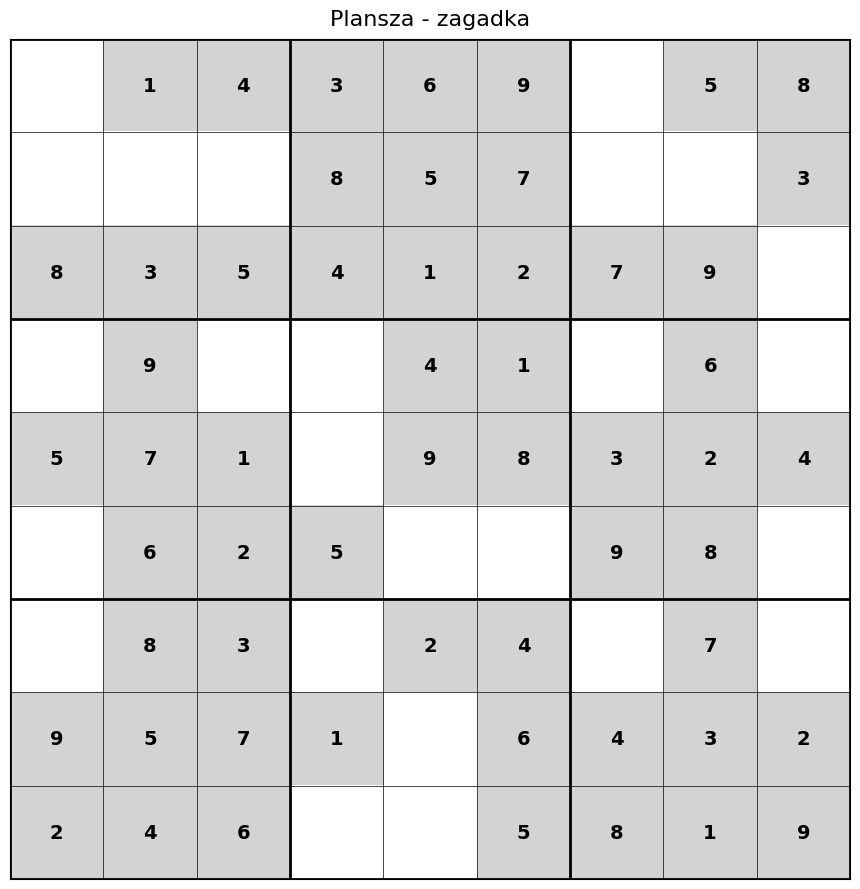


Uruchomienie algorytmu...
Numer pokolenia 0: dopasowanie = -9
Numer pokolenia 7: dopasowanie = 0
Znaleziono rozwiązanie!

Czas wykonywania: 0.61 seconds
Wartość najlepszego dopasowania: 0


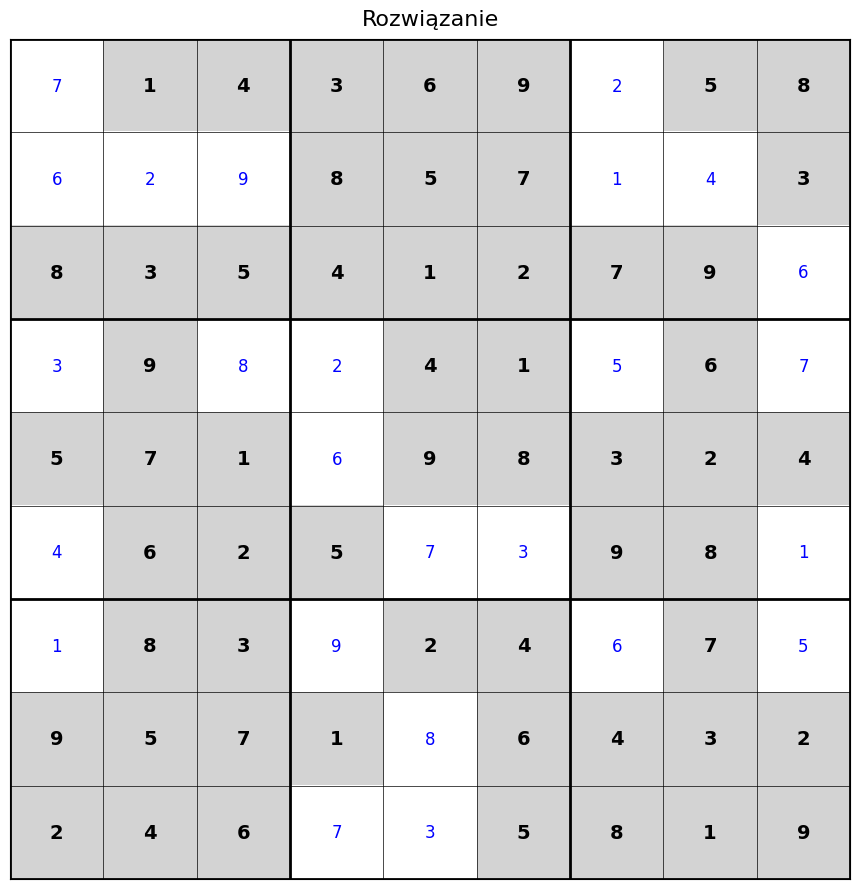

In [ ]:
# Funkcja Main

if __name__ == "__main__":

    # Parametry algorytmu

    POP_SIZE = 1000       # Rozmiar populacji
    GENERATIONS = 1000    # Ilość generacji (pokoleń)
    PM = 0.1              # Prawdopodobieństwo mutacji
    PC = 0.95             # Prawdopodobieństwo krzyżowania

    ILE_POL = 25          # Liczba pustych pól - trudność zagadki
    SIZE=9                # Rozmiar planszy
    BOX_SIZE = 3          # Rozmiar sub-planszy
    SUDOKU = np.zeros((SIZE, SIZE), dtype=int)    # Generowanie pustej planszy (typu int)


    # Wczytanie planszy

    initial_board = losowanie(SUDOKU, ILE_POL)
    if initial_board is None:                 # Wyjście z programu jeśli błąd planszy
        exit()

    # Wyświetlanie pustej planszy

    display_sudoku(initial_board, title="Plansza - zagadka")

    # Uruchomienie algorytmu

    print("\nUruchomienie algorytmu...")              # Info powitalne - konsola
    start_time = time.time()                          # Pomiar czasu wykonania- start

    # Wywołanie właściwe funkcji algorytmu ewolucyjnego

    best_solution = genetic_algorithm(initial_board, POP_SIZE, GENERATIONS, PM, PC)

    end_time = time.time()                            # Pomiar czasu wykonania - stop

    # Wynik (najlepszy i/lub prawidłowy)
    best_fitness = get_fitness(best_solution)

    # Info na konsolę - czas wykonania
    print(f"\nCzas wykonywania: {end_time - start_time:.2f} seconds")
    # Jeśli zero - plansza rozwiązana prawidłowo
    print(f"Wartość najlepszego dopasowania: {best_fitness}")

    # Wyświetl rozwiązaną zagadkę SUUDOKU

    display_sudoku(initial_board, best_solution, title="Rozwiązanie")